In [146]:
import pandas as pd
from scipy.stats import skew
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
import numpy as np

In [147]:
df = pd.read_csv("datasets/taxi_trip_pricing.csv")
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [148]:
print(f"Total Observations (rows): {df.shape[0]}")
print(f"Total Features (columns): {df.shape[1]}")

Total Observations (rows): 1000
Total Features (columns): 11


In [149]:
#Global informations about the dataset (Columns, shape, types, missing values...) 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    str    
 2   Day_of_Week            950 non-null    str    
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    str    
 5   Weather                950 non-null    str    
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), str(4)
memory usage: 108.5 KB


In [150]:
#Check for Duplicate Values
duplicate_count = len(df[df.duplicated()])

if (duplicate_count>0):
    print(f"Before: {df.shape[0]}")
    print(f"{duplicate_count} Duplicate values found in the data.")
    df.drop_duplicates(inplace=True)
    print(f"After: {df.shape[0]}")
else:
    print("No duplicate values detected in the data.")

No duplicate values detected in the data.


In [151]:
for column in df.columns:
    if df[column].dtype == "str":
        print(f"{column} : {list(df[column].unique())}")

Time_of_Day : ['Morning', 'Afternoon', 'Evening', 'Night', nan]
Day_of_Week : ['Weekday', 'Weekend', nan]
Traffic_Conditions : ['Low', 'High', 'Medium', nan]
Weather : ['Clear', nan, 'Rain', 'Snow']


In [152]:
def check_missing_values(data):
    missing = data.isnull().sum()
    missing = missing[missing > 0].sort_values()
    return missing

print(check_missing_values(df))

Trip_Price               49
Trip_Distance_km         50
Day_of_Week              50
Time_of_Day              50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Passenger_Count          50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
dtype: int64


In [153]:
categorical_nominal = ["Time_of_Day", "Day_of_Week", "Weather"]
categorical_ordinal = ["Traffic_Conditions"]
bounded_numerical = ["Passenger_Count"]
unbounded_numerical = ["Trip_Distance_km", "Trip_Duration_Minutes", "Base_Fare", "Per_Km_Rate", "Per_Minute_Rate"]
numerical_features = bounded_numerical + unbounded_numerical
categorical_features = categorical_nominal + categorical_ordinal

In [154]:
X = df.drop(columns=['Trip_Price'])
y = df['Trip_Price']
X = X[y.notna()]
y = y[y.notna()]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [155]:
def impute_numerical_features(X_train, X_test, columns, skew_threshold=0.5):
    for column in columns:
        data = X_train[column].dropna()
        sk = skew(data)

        if abs(sk) < skew_threshold:
            interpretation = "Approximately symmetric"
            imputation_value = data.mean()
        else:
            interpretation = "Skewed"
            imputation_value = data.median()
        X_train.loc[:, column] = X_train[column].fillna(imputation_value)
        X_test.loc[:, column] = X_test[column].fillna(imputation_value)

    return X_train, X_test

X_train, X_test = impute_numerical_features(X_train, X_test, numerical_features)

In [156]:
def impute_categorical_features(X_train, X_test, columns):
    imputation_values = {}
    
    for column in columns:
        data = X_train[column].dropna()
        mode_value = data.mode()[0]

        X_train.loc[:, column] = X_train[column].fillna(mode_value)
        X_test.loc[:, column] = X_test[column].fillna(mode_value)

    return X_train, X_test

X_train, X_test = impute_categorical_features(X_train, X_test, categorical_features)

In [157]:
print(f"X_train missing values: {check_missing_values(X_train)}")
print(f"X_test missing values: {check_missing_values(X_test)}")

X_train missing values: Series([], dtype: int64)
X_test missing values: Series([], dtype: int64)


In [158]:
def encode_nominal_features(X_train: pd.DataFrame, X_test: pd.DataFrame, categorical_nominal: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, OneHotEncoder]:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    one_hot_train = encoder.fit_transform(X_train[categorical_nominal])
    one_hot_test = encoder.transform(X_test[categorical_nominal])
    ohe_cols = encoder.get_feature_names_out(categorical_nominal)
    
    X_train = pd.concat([
        X_train.drop(columns=categorical_nominal),
        pd.DataFrame(one_hot_train, columns=ohe_cols, index=X_train.index)
    ], axis=1)
    
    X_test = pd.concat([
        X_test.drop(columns=categorical_nominal),
        pd.DataFrame(one_hot_test, columns=ohe_cols, index=X_test.index)
    ], axis=1)

    return X_train, X_test, encoder

def encode_ordinal_features(X_train, X_test, columns, mapping):
    for column in columns:
        X_train[column] = X_train[column].map(mapping)
        X_test[column] = X_test[column].map(mapping)

        X_train[column] = X_train[column].astype(float)
        X_test[column] = X_test[column].astype(float)
    return X_train, X_test

def normalization(X_train: pd.DataFrame, X_test: pd.DataFrame, bounded_numerical: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, MinMaxScaler]:
    scaler = MinMaxScaler()
    
    X_train[bounded_numerical] = scaler.fit_transform(X_train[bounded_numerical])
    X_test[bounded_numerical] = scaler.transform(X_test[bounded_numerical])
    
    return X_train, X_test, scaler

def standardization(X_train: pd.DataFrame, X_test: pd.DataFrame, unbounded_numerical: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, StandardScaler]:
    scaler = StandardScaler()
    
    X_train[unbounded_numerical] = scaler.fit_transform(X_train[unbounded_numerical])
    X_test[unbounded_numerical] = scaler.transform(X_test[unbounded_numerical])

    return X_train, X_test, scaler


In [159]:
X_train, X_test, encoder = encode_nominal_features(X_train, X_test, categorical_nominal)
X_train, X_test, min_max_scaler = normalization(X_train, X_test, bounded_numerical)
X_train, X_test, standar_scaler = standardization(X_train, X_test, unbounded_numerical)

mapping_traffic = {'Low': 0, 'Medium': 1, 'High': 2}
X_train, X_test = encode_ordinal_features(X_train, X_test, categorical_ordinal, mapping_traffic)

In [160]:
model = LinearRegression()
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)

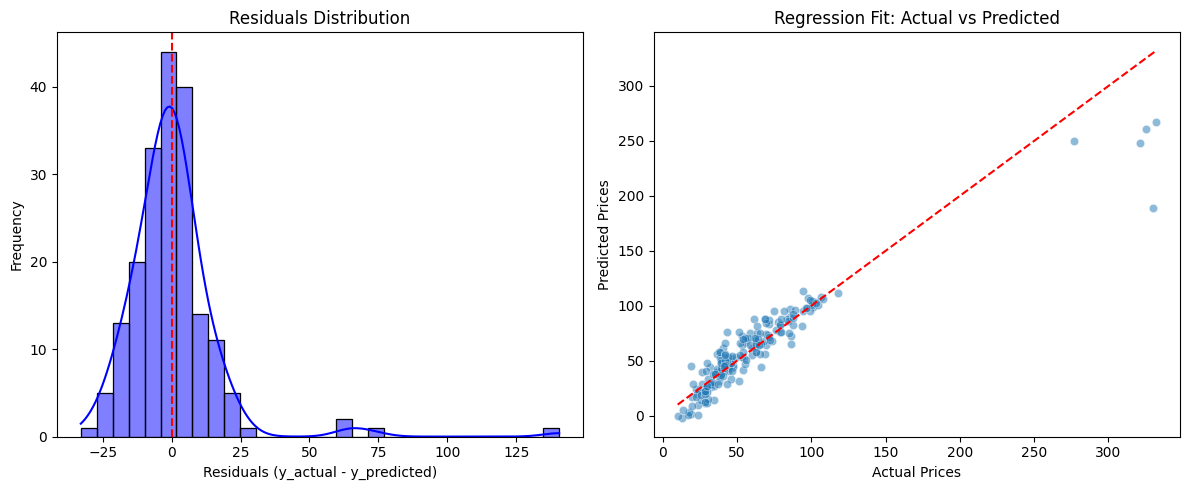

In [161]:
residuals = y_test - y_predicted

plt.figure(figsize=(12,5))


# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")


# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)
sns.scatterplot(x=y_test, y=y_predicted, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")


# Show plots.
plt.tight_layout()
plt.show()

In [162]:
print("mean squared error : ", mean_squared_error(y_predicted, y_test))
print("mean absolute error : ", mean_absolute_error(y_predicted, y_test))
print("R2 : ", r2_score(y_test, y_predicted))

mean squared error :  288.13692177246577
mean absolute error :  9.939832347078532
R2 :  0.8767264788265137


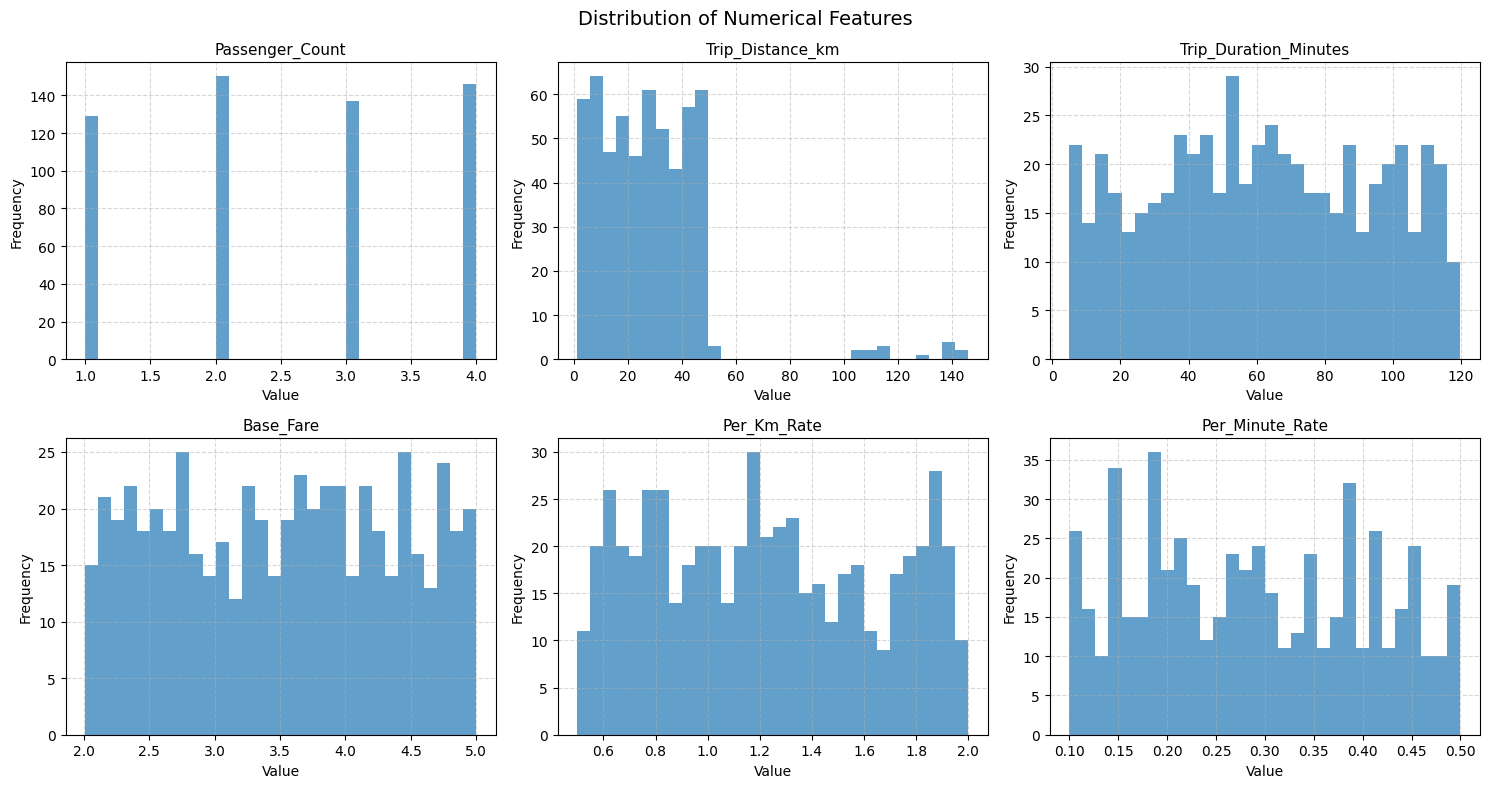

In [163]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_features):
    axes[i].hist(X.dropna()[column], bins=30, alpha=0.7)
    
    axes[i].set_title(column, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    
    axes[i].grid(True, linestyle='--', alpha=0.5)

for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Numerical Features', fontsize=14)

plt.tight_layout()
plt.show()

In [164]:
def fit_outlier_bounds(X, columns):
    bounds = {}
    
    for column in columns:
        Q1 = X[column].quantile(0.25)
        Q3 = X[column].quantile(0.75)
        IQR = Q3 - Q1
        
        bounds[column] = {
            "lower": Q1 - 1.5 * IQR,
            "upper": Q3 + 1.5 * IQR
        }
    
    return bounds


def remove_outliers(X, y, bounds):
    mask = pd.Series(True, index=X.index)
    
    for column, bound in bounds.items():
        mask &= (X[column] >= bound["lower"]) & (X[column] <= bound["upper"])
    
    return X[mask], y[mask]

In [165]:
# 1. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Imputation
X_train, X_test = impute_numerical_features(X_train, X_test, numerical_features)
X_train, X_test = impute_categorical_features(X_train, X_test, categorical_features)

# 3. Encoding
X_train, X_test, encoder = encode_nominal_features(X_train, X_test, categorical_nominal)
X_train, X_test = encode_ordinal_features(X_train, X_test, categorical_ordinal, mapping_traffic)

# 4. Outliers
bounds = fit_outlier_bounds(X_train, numerical_features)
X_train, y_train = remove_outliers(X_train, y_train, bounds)
X_test, y_test = remove_outliers(X_test, y_test, bounds)

# 5. Scaling
X_train, X_test, min_max_scaler = normalization(X_train, X_test, bounded_numerical)
X_train, X_test, standar_scaler = standardization(X_train, X_test, unbounded_numerical)

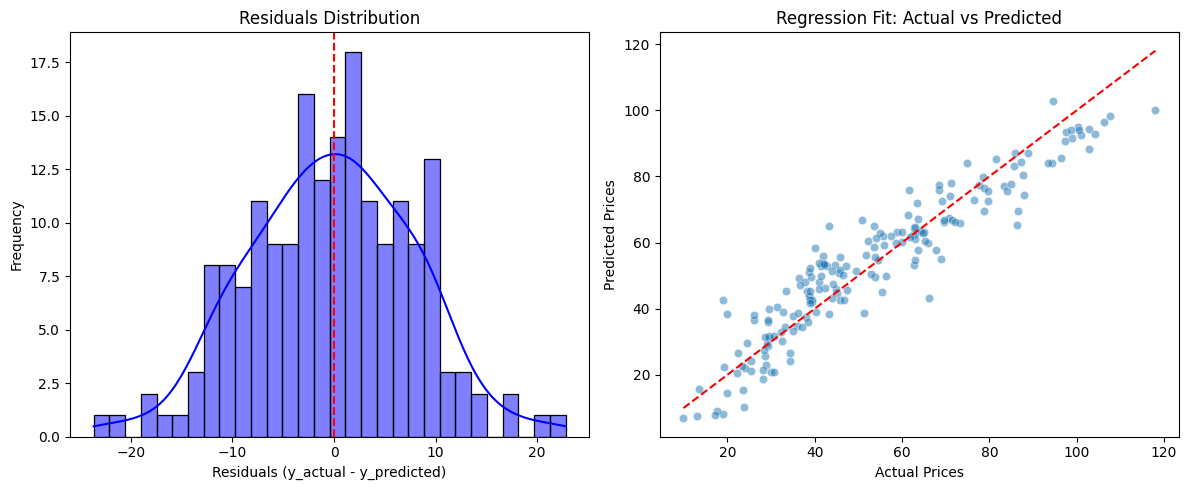

In [166]:
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
residuals = y_test - y_predicted

plt.figure(figsize=(12,5))


# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")


# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)
sns.scatterplot(x=y_test, y=y_predicted, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")


# Show plots.
plt.tight_layout()
plt.show()

In [167]:
print("mean squared error : ", mean_squared_error(y_predicted, y_test))
print("mean absolute error : ", mean_absolute_error(y_predicted, y_test))
print("R2 : ", r2_score(y_test, y_predicted))

mean squared error :  64.98030085915521
mean absolute error :  6.468710203420879
R2 :  0.8858720275819121


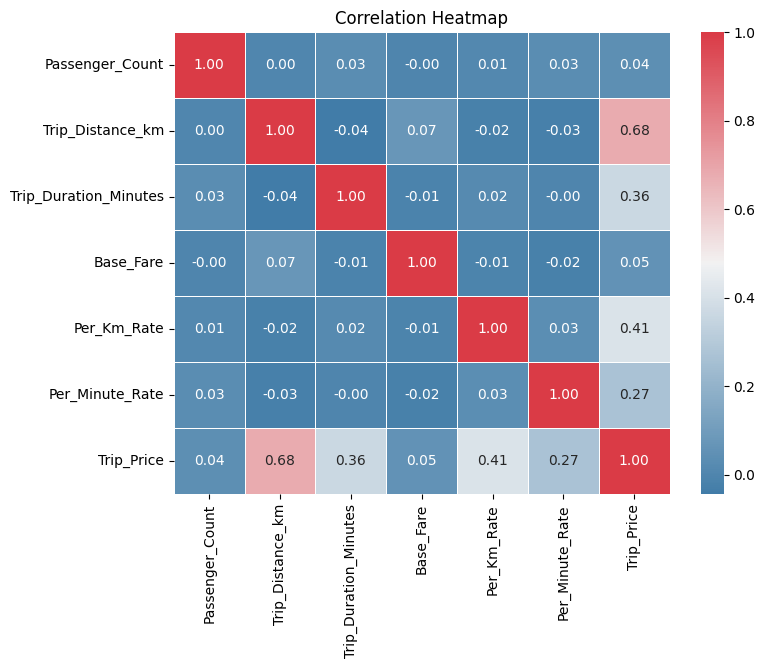

In [168]:
matrix = pd.concat([X_train[numerical_features], y_train], axis=1).corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap=sns.diverging_palette(240, 10, as_cmap=True), fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [169]:
def variance_inflation_factor(X, feature):
    others = X.drop(columns=[feature])
    y = X[feature]
    model = LinearRegression()
    model.fit(others, y)
    r2 = r2_score(y, model.predict(others))
    return 1 / 1 - r2

vifs = []
for column in numerical_features:
    vifs.append((column, variance_inflation_factor(X_train, column)))

vifs.sort(key=lambda x: x[1], reverse=True)
for feature, vif in vifs:
    print(f"Feature : {feature} -> Vif : {vif}")

Feature : Passenger_Count -> Vif : 0.9923125533514455
Feature : Trip_Duration_Minutes -> Vif : 0.9920677246335996
Feature : Per_Km_Rate -> Vif : 0.9894719124348385
Feature : Per_Minute_Rate -> Vif : 0.9893693567267914
Feature : Base_Fare -> Vif : 0.9890682244532167
Feature : Trip_Distance_km -> Vif : 0.9814679347180321


In [170]:
X_train["Distance_Cost"] = X_train["Trip_Distance_km"] * X_train["Per_Km_Rate"]
X_train["Time_Cost"] = X_train["Trip_Duration_Minutes"] * X_train["Per_Minute_Rate"]
X_train["Avg_Speed"] = X_train["Trip_Distance_km"] * X_train["Trip_Duration_Minutes"]

X_test["Distance_Cost"] = X_test["Trip_Distance_km"] * X_test["Per_Km_Rate"]
X_test["Time_Cost"] = X_test["Trip_Duration_Minutes"] * X_test["Per_Minute_Rate"]
X_test["Avg_Speed"] = X_test["Trip_Distance_km"] * X_test["Trip_Duration_Minutes"]

In [171]:
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)

print("mean squared error : ", mean_squared_error(y_predicted, y_test))
print("mean absolute error : ", mean_absolute_error(y_predicted, y_test))
print("R2 : ", r2_score(y_test, y_predicted))

mean squared error :  19.352235124923652
mean absolute error :  1.818539032351178
R2 :  0.9660107551463505


In [172]:
print("Intercept:", model.intercept_)


coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": model.coef_})

Intercept: 52.10132108106126


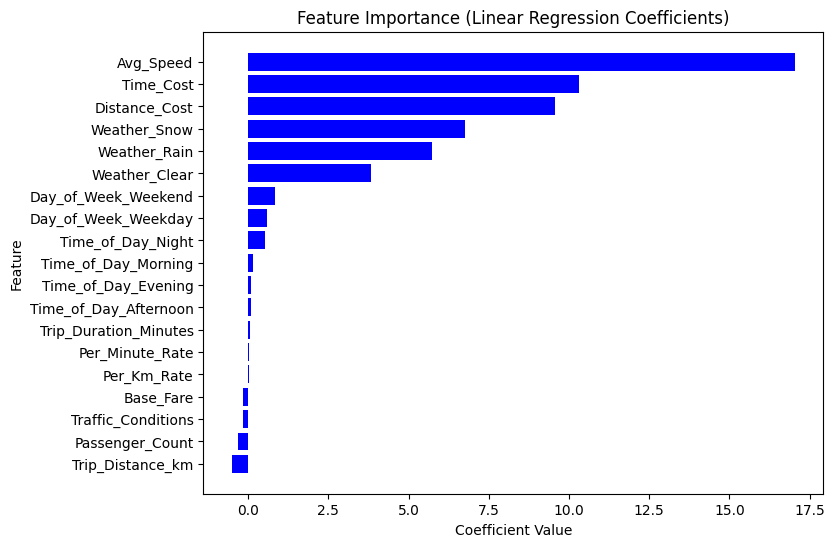

In [173]:
coef_df_sorted = coef_df.sort_values(by="Coefficient")

plt.figure(figsize=(8,6))
plt.barh(coef_df["Feature"], coef_df_sorted["Coefficient"], color="blue")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()

In [174]:
def f(X: pd.DataFrame, w: pd.Series, b: float) -> pd.Series:
    return X.dot(w) + b

def squared_error_cost(y: pd.Series, y_hat: pd.Series) -> float:
    return ((y - y_hat).pow(2)).mean() / 2

def db(y: pd.Series, y_hat: pd.Series) -> float:
    return (y_hat - y).mean()

def dw(X: pd.DataFrame, y: pd.Series, y_hat: pd.Series) -> pd.Series:
    return X.T.dot(y_hat - y) / len(y)

In [196]:
def gradient_descent(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    alpha: float = 0.05,
    max_iter: int = 500,
    epsilon: float = 1e-6
):
    w = pd.Series(0.0, index=X_train.columns)
    b = 0.0
    nbr_iter = 0
    costs_train, costs_test = [], []
    r2_scores_train, r2_scores_test = [], []

    while nbr_iter < max_iter:
        y_hat_train = f(X_train, w, b)
        tmp_w = w - alpha * dw(X_train, y_train, y_hat_train)
        tmp_b = b - alpha * db(y_train, y_hat_train)
        w, b = tmp_w, tmp_b
        nbr_iter += 1

        y_hat_train = f(X_train, w, b)
        y_hat_test  = f(X_test,  w, b)

        r2_scores_train.append(r2_score(y_train, y_hat_train))
        r2_scores_test.append(r2_score(y_test, y_hat_test))
        costs_train.append(float(squared_error_cost(y_train, y_hat_train)))
        costs_test.append(float(squared_error_cost(y_test,  y_hat_test)))

        if nbr_iter > 1 and abs(costs_train[-2] - costs_train[-1]) < epsilon:
            break

    return w, b, r2_scores_train, r2_scores_test, costs_train, costs_test

In [197]:
w, b, r2_scores_train, r2_scores_test, costs_train, costs_test = gradient_descent(X_train, y_train, X_test, y_test)

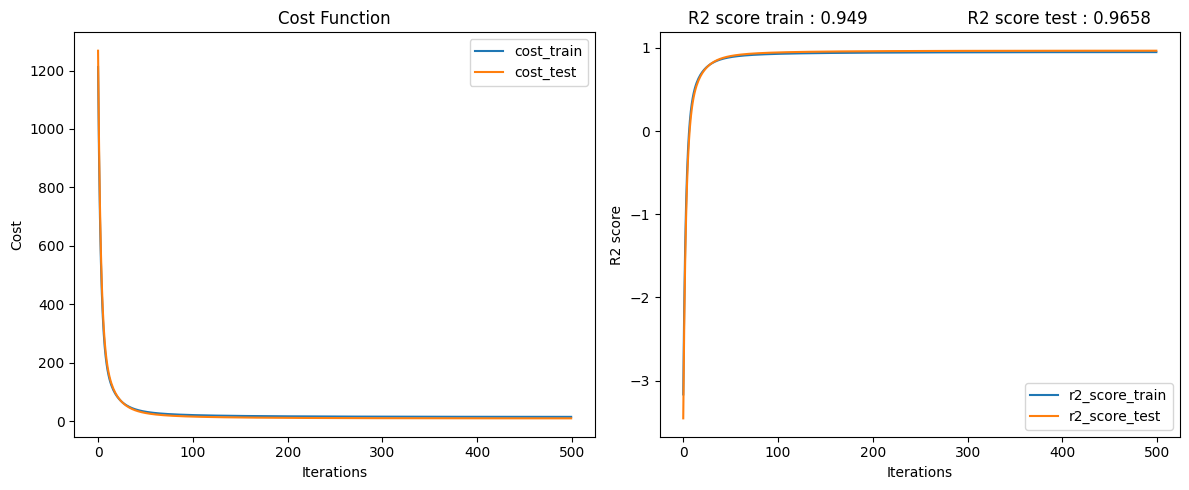

In [198]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(range(len(costs_train)), costs_train, label="cost_train")
ax1.plot(range(len(costs_test)), costs_test, label="cost_test")
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Cost')
ax1.set_title('Cost Function')
ax1.legend()

ax2.plot(range(len(r2_scores_train)), r2_scores_train, label="r2_score_train")
ax2.plot(range(len(r2_scores_test)), r2_scores_test, label="r2_score_test")
ax2.set_xlabel('Iterations')
ax2.set_ylabel('R2 score')
ax2.set_title(f"R2 score train : {r2_scores_train[-1]:0.4}                   R2 score test : {r2_scores_test[-1]:0.4}")
ax2.legend()

plt.tight_layout()
plt.show()